In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# Load the dataset
df = pd.read_csv('renfe_trains.csv') 

In [0]:
df

,company,origin,destination,departure,arrival,vehicle_class,price,fare
0,renfe,MADRID,SEVILLA,2019-05-07 19:00:00,2019-05-07 21:38:00,Preferente,69.4,Promo
1,renfe,MADRID,SEVILLA,2019-05-07 21:25:00,2019-05-08 00:10:00,Turista,43.55,Promo
2,renfe,MADRID,BARCELONA,2019-05-11 08:30:00,2019-05-11 11:15:00,Turista,85.1,Promo
3,renfe,MADRID,BARCELONA,2019-04-18 14:30:00,2019-04-18 17:21:00,Turista,107.7,Flexible
4,renfe,MADRID,BARCELONA,2019-04-28 16:30:00,2019-04-28 19:15:00,Turista,107.7,Flexible
...,...,...,...,...,...,...,...,...
85943,renfe,MADRID,BARCELONA,2020-10-20 08:00:00,2020-10-20 10:30:00,Turista,55.25,Promo +
85944,renfe,MADRID,BARCELONA,2020-10-27 09:30:00,2020-10-27 12:34:12,Turista,55.55,Promo +
85945,renfe,MADRID,BARCELONA,2020-10-23 07:30:00,2020-10-23 10:40:12,Turista,46.85,Promo +
85946,renfe,MADRID,BARCELONA,2020-10-08 07:40:00,2020-10-08 13:55:00,Turista con enlace,96.7,Flexible


In [0]:
df.dtypes


company          object
origin           object
destination      object
departure        object
arrival          object
vehicle_class    object
price            object
fare             object
dtype: object

In [0]:
# Check non numeric values within price
bad_prices = df[df['price'] == 'price']
print(f"Bad 'price' values found: {bad_prices.shape[0]} rows")
print(bad_prices)

# Drop rows where price is 'price'
df_clean = df[df['price'] != 'price'].copy()

# Convert price to numeric
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

print(df_clean.dtypes)


Bad 'price' values found: 3875 rows
       company  origin  destination  ...  vehicle_class  price  fare
69     company  origin  destination  ...  vehicle_class  price  fare
146    company  origin  destination  ...  vehicle_class  price  fare
209    company  origin  destination  ...  vehicle_class  price  fare
287    company  origin  destination  ...  vehicle_class  price  fare
347    company  origin  destination  ...  vehicle_class  price  fare
...        ...     ...          ...  ...            ...    ...   ...
85903  company  origin  destination  ...  vehicle_class  price  fare
85908  company  origin  destination  ...  vehicle_class  price  fare
85921  company  origin  destination  ...  vehicle_class  price  fare
85934  company  origin  destination  ...  vehicle_class  price  fare
85942  company  origin  destination  ...  vehicle_class  price  fare

[3875 rows x 8 columns]
company           object
origin            object
destination       object
departure         object
arrival    

In [0]:
# stats
mean_price = df_clean['price'].mean()
median_price = df_clean['price'].median()
std_price = df_clean['price'].std()
iqr_price = df_clean['price'].quantile(0.75) - df_clean['price'].quantile(0.25)

print(f"Mean: {mean_price:.2f}, Median: {median_price:.2f}, Std: {std_price:.2f}, IQR: {iqr_price:.2f}")


Mean: 71.49, Median: 69.40, Std: 23.85, IQR: 31.70


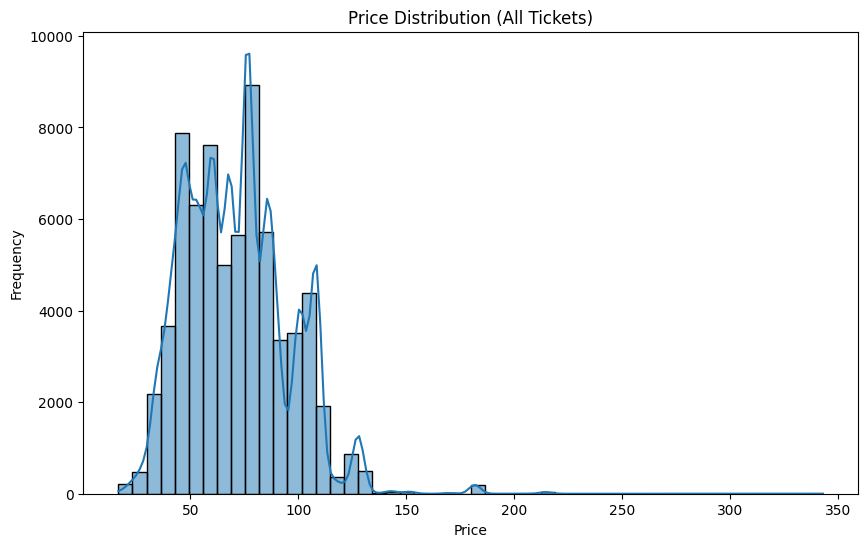

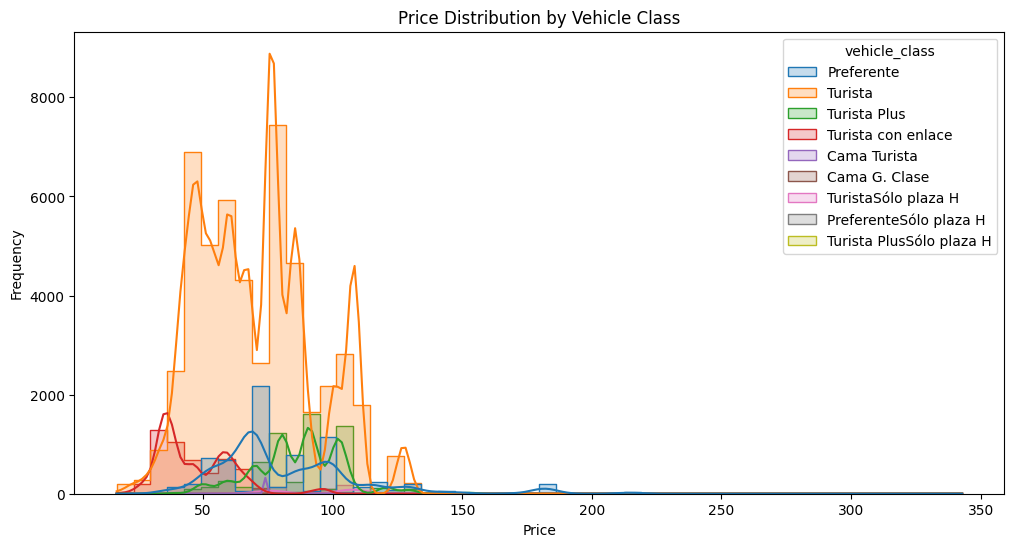

In [0]:
# Histogram of price
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Price Distribution (All Tickets)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Histogram by vehicle class
plt.figure(figsize=(12, 6))
sns.histplot(data=df_clean, x='price', hue='vehicle_class', element='step', bins=50, kde=True)
plt.title('Price Distribution by Vehicle Class')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


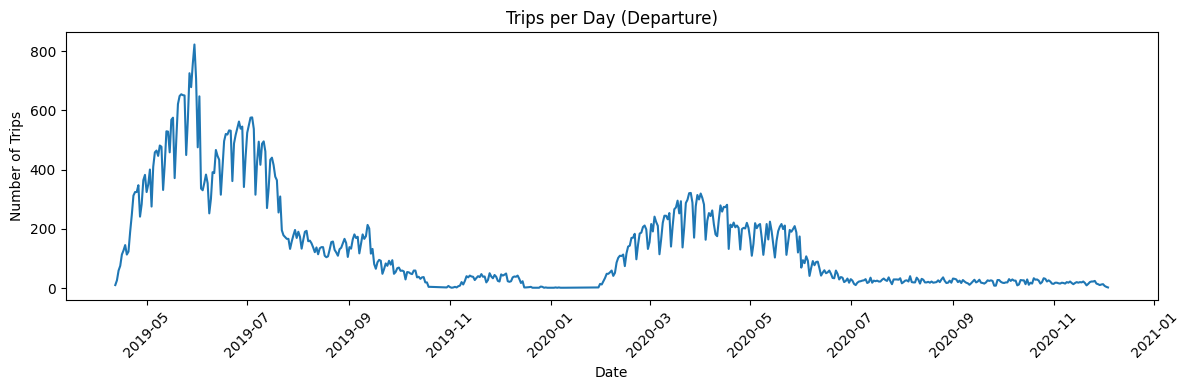

In [0]:
# Convert to datetime
df_clean['departure'] = pd.to_datetime(df_clean['departure'], errors='coerce')
df_clean['arrival'] = pd.to_datetime(df_clean['arrival'], errors='coerce')

# Plotting the departure dates
plt.figure(figsize=(12, 4))
df_clean['departure'].dt.date.value_counts().sort_index().plot()
plt.title('Trips per Day (Departure)')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


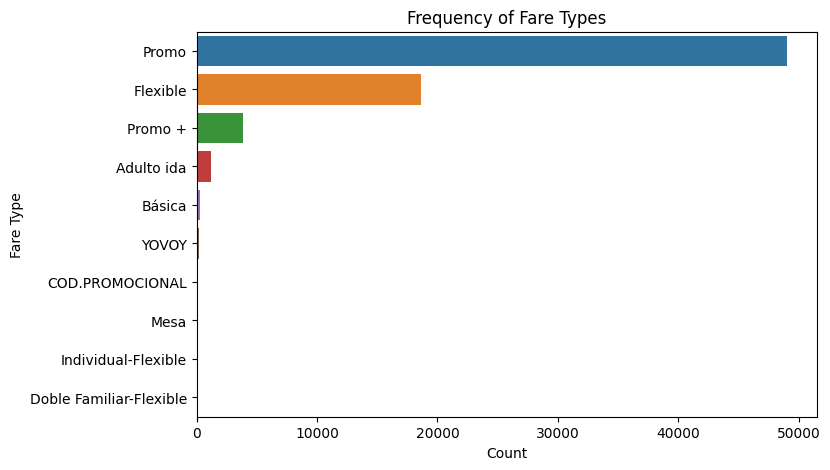

In [0]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, y='fare', order=df_clean['fare'].value_counts().index)
plt.title('Frequency of Fare Types')
plt.xlabel('Count')
plt.ylabel('Fare Type')
plt.show()


In [0]:
# Count missing values
missing_counts = df_clean.isnull().sum()
print(missing_counts)

# Show examples
df_clean[df_clean[['vehicle_class', 'price', 'fare']].isnull().any(axis=1)].head()


company              0
origin               0
destination          0
departure            0
arrival              0
vehicle_class     8832
price            13179
fare              8832
dtype: int64


,company,origin,destination,departure,arrival,vehicle_class,price,fare
11,renfe,MADRID,BARCELONA,2019-05-03 18:30:00,2019-05-03 21:20:00,Preferente,NaN,Promo
15,renfe,MADRID,BARCELONA,2019-04-23 07:30:00,2019-04-23 10:40:00,Turista,NaN,Promo
33,renfe,MADRID,SEVILLA,2019-04-21 21:25:00,2019-04-22 00:10:00,NaN,NaN,NaN
52,renfe,MADRID,SEVILLA,2019-04-17 09:45:00,2019-04-17 12:27:00,Turista,NaN,Flexible
65,renfe,MADRID,SEVILLA,2019-05-03 13:30:00,2019-05-03 16:05:00,Turista,NaN,Promo


In [0]:
df_clean = df_clean.dropna(subset=['vehicle_class', 'price', 'fare'])
print(f"Remaining rows after dropping: {df_clean.shape[0]}")


Remaining rows after dropping: 68894


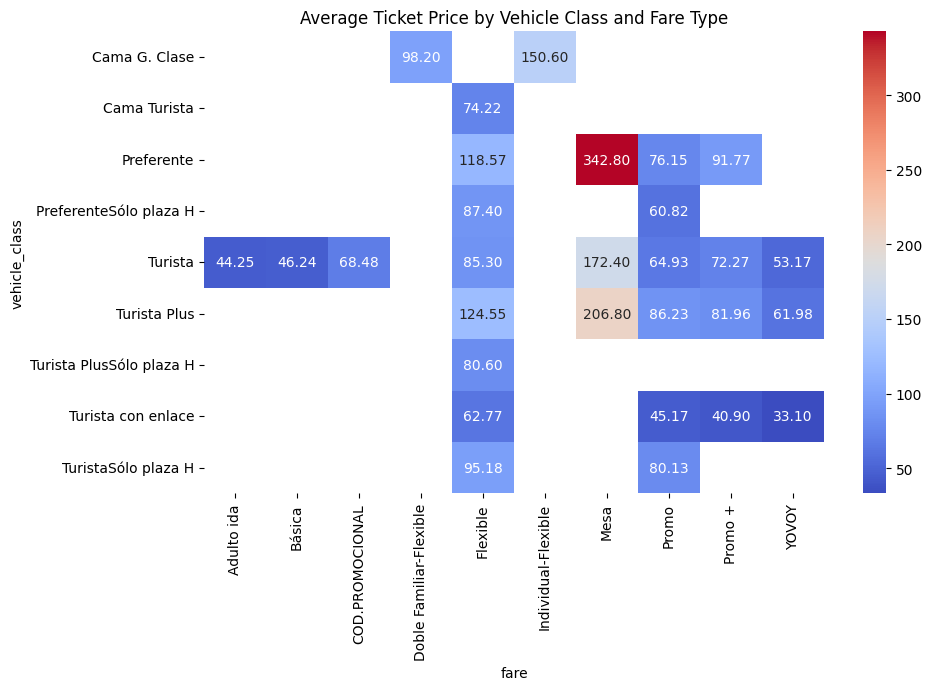

In [0]:
# Group mean prices
grouped = df_clean.groupby(['vehicle_class', 'fare'])['price'].mean().reset_index()

# Heatmap-style plot
pivot_table = grouped.pivot(index='vehicle_class', columns='fare', values='price')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Average Ticket Price by Vehicle Class and Fare Type')
plt.show()


In [0]:
# Re-check missing
print("Missing price entries before filling:", df_clean['price'].isnull().sum())

# Fill with mean
price_mean = df_clean['price'].mean()
df_clean['price'] = df_clean['price'].fillna(price_mean)

# Confirm
print("Missing price entries after filling:", df_clean['price'].isnull().sum())


Missing price entries before filling: 0
Missing price entries after filling: 0


In [0]:
# Check duplicates
duplicates = df_clean.duplicated()
print(f"Total duplicates: {duplicates.sum()}")

# If keeping them, add a unique ID
df_clean = df_clean.reset_index(drop=True)
df_clean['ticket_id'] = df_clean.index + 1


Total duplicates: 41387


In [0]:
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers
outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]
print(f"Outliers detected: {outliers.shape[0]}")


Outliers detected: 376


In [0]:
# Compute group means
group_means = df_clean.groupby(['vehicle_class', 'fare'])['price'].transform('mean')

# New column with advanced imputation
df_clean['price_group_imputed'] = df_clean['price']  # Copy base price
df_clean.loc[df_clean['price'].isnull(), 'price_group_imputed'] = group_means


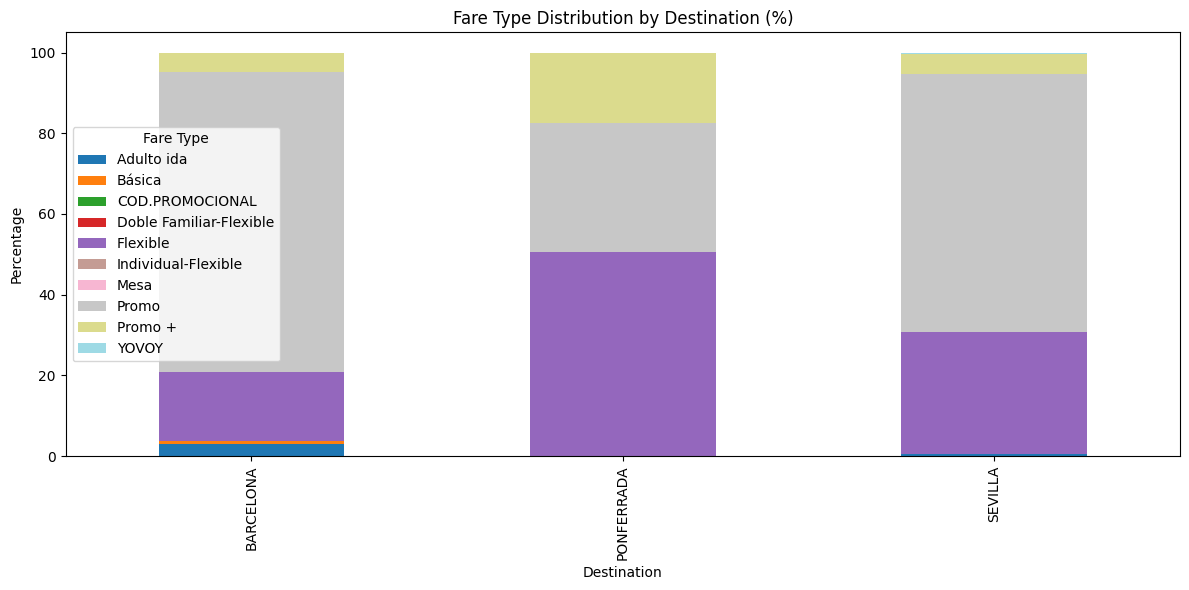

In [0]:
# Crosstab
fare_dist = pd.crosstab(df_clean['destination'], df_clean['fare'], normalize='index') * 100

# Plot
fare_dist.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Fare Type Distribution by Destination (%)')
plt.xlabel('Destination')
plt.ylabel('Percentage')
plt.legend(title='Fare Type')
plt.tight_layout()
plt.show()
